## Import modules

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Generate datasets

In [2]:
np.random.seed(42)
torch.manual_seed(42)

lambda1_true = 1.0
lambda2_true = 0.01

data = sp.io.loadmat("cylinder_nektar_wake.mat")
X_star = data['X_star']
t = data['t']
U_star = data['U_star']
p_star = data['p_star']

n_space = X_star.shape[0]
n_time = t.shape[0]

X_data = np.tile(X_star[:, 0:1], (1, n_time)).reshape(-1, 1)
Y_data = np.tile(X_star[:, 1:2], (1, n_time)).reshape(-1, 1)
T_data = np.tile(t, (n_space, 1))
XYT_data = np.hstack([X_data, Y_data, T_data])

u_data = U_star[:, 0, :].reshape(-1, 1)
v_data = U_star[:, 1, :].reshape(-1, 1)
p_data = p_star.reshape(-1, 1)

XYT_data = torch.tensor(XYT_data, dtype=torch.float).requires_grad_(True)
u_data = torch.tensor(u_data, dtype=torch.float)
v_data = torch.tensor(v_data, dtype=torch.float)
p_data = torch.tensor(p_data, dtype=torch.float)

n_train = 5000
idx = np.random.choice(n_space*n_time, n_train, replace=False)
XYT_train = XYT_data[idx, :].clone().detach().requires_grad_(True)
u_train = u_data[idx, :].clone().detach().requires_grad_(False)
v_train = v_data[idx, :].clone().detach().requires_grad_(False)
p_train = p_data[idx, :].clone().detach().requires_grad_(False)

ubs = XYT_train.max(axis=0).values.detach()
lbs = XYT_train.min(axis=0).values.detach()
scaled_XYT_data = 2 * (XYT_data - lbs) / (ubs - lbs) - 1

## Define model

In [3]:
model = nn.Sequential(
    nn.Linear(3, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 2)
)

lambda1 = nn.Parameter(torch.tensor([2.0], dtype=torch.float))
lambda2 = nn.Parameter(torch.tensor([2.0], dtype=torch.float))

## Compute residuals

In [4]:
def grad(outputs, inputs):
    derivative = torch.autograd.grad(
        outputs = outputs,
        inputs = inputs,
        grad_outputs = torch.ones_like(outputs),
        create_graph = True,
        retain_graph = True
    )[0]
    return derivative

def residuals(psi, p):
    grad_psi = grad(psi, XYT_train)
    u = grad_psi[:, 1:2]
    v = grad_psi[:, 0:1] * -1

    grad_u = grad(u, XYT_train)
    ux = grad_u[:, 0:1]
    uy = grad_u[:, 1:2]
    ut = grad_u[:, 2:3]

    grad_v = grad(v, XYT_train)
    vx = grad_v[:, 0:1]
    vy = grad_v[:, 1:2]
    vt = grad_v[:, 2:3]

    grad_ux = grad(ux, XYT_train)
    uxx = grad_ux[:, 0:1]

    grad_uy = grad(uy, XYT_train)
    uyy = grad_uy[:, 1:2]

    grad_vx = grad(vx, XYT_train)
    vxx = grad_vx[:, 0:1]

    grad_vy = grad(vy, XYT_train)
    vyy = grad_vy[:, 1:2]

    grad_p = grad(p, XYT_train)
    px = grad_p[:, 0:1]
    py = grad_p[:, 1:2]

    f = ut + lambda1 * (u*ux + v*uy) + px - lambda2 * (uxx + uyy)
    g = vt + lambda1 * (u*vx + v*vy) + py - lambda2 * (vxx + vyy)

    return f, g, u, v

## Define loss function

In [5]:
def loss_fcn(u_train, v_train, psi_pred, p_pred):
    f, g, u_pred, v_pred = residuals(psi_pred, p_pred)
    data_loss = torch.mean((u_pred - u_train)**2 + (v_pred - v_train)**2)
    residual_loss = torch.mean(f**2 + g**2)
    total_loss =  data_loss + residual_loss
    return total_loss, data_loss, residual_loss

## Training cycle

In [6]:
data_loss_list = []
residual_loss_list = []
total_loss_list = []
lambda1_list = []
lambda2_list = []

adam_optimizer = torch.optim.Adam(list(model.parameters()) + [lambda1, lambda2])

for i in range(0, 200000):
    scaled_XYT_train = 2 * (XYT_train - lbs) / (ubs - lbs) - 1
    model.train()
    psi_p_pred = model(scaled_XYT_train)
    psi_pred = psi_p_pred[:, 0:1]
    p_pred = psi_p_pred[:, 1:2]

    total_loss, data_loss, residual_loss = loss_fcn(u_train, v_train, psi_pred, p_pred)
    adam_optimizer.zero_grad()
    total_loss.backward()
    adam_optimizer.step()

    data_loss_list.append(data_loss.item())
    residual_loss_list.append(residual_loss.item())
    total_loss_list.append(total_loss.item())
    lambda1_list.append(lambda1.item())
    lambda2_list.append(lambda2.item())

    if i % 500 == 0:
        print(f'epoch:', i)

print('Adam finished')

lbfgs_optimizer = torch.optim.LBFGS(
    params = list(model.parameters()) + [lambda1, lambda2],
    max_iter = 50000,
    history_size = 50,
    tolerance_grad = 1e-9,
    tolerance_change = np.finfo(float).eps,
    line_search_fn = 'strong_wolfe'
)

epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000
epoch: 2500
epoch: 3000
epoch: 3500
epoch: 4000
epoch: 4500
epoch: 5000
epoch: 5500
epoch: 6000
epoch: 6500
epoch: 7000
epoch: 7500
epoch: 8000
epoch: 8500
epoch: 9000
epoch: 9500
epoch: 10000
epoch: 10500
epoch: 11000
epoch: 11500
epoch: 12000
epoch: 12500
epoch: 13000
epoch: 13500
epoch: 14000
epoch: 14500
epoch: 15000
epoch: 15500
epoch: 16000
epoch: 16500
epoch: 17000
epoch: 17500
epoch: 18000
epoch: 18500
epoch: 19000
epoch: 19500
epoch: 20000
epoch: 20500
epoch: 21000
epoch: 21500
epoch: 22000
epoch: 22500
epoch: 23000
epoch: 23500
epoch: 24000
epoch: 24500
epoch: 25000
epoch: 25500
epoch: 26000
epoch: 26500
epoch: 27000
epoch: 27500
epoch: 28000
epoch: 28500
epoch: 29000
epoch: 29500
epoch: 30000
epoch: 30500
epoch: 31000
epoch: 31500
epoch: 32000
epoch: 32500
epoch: 33000
epoch: 33500
epoch: 34000
epoch: 34500
epoch: 35000
epoch: 35500
epoch: 36000
epoch: 36500
epoch: 37000
epoch: 37500
epoch: 38000
epoch: 38500
epoch: 390

## Plot losses

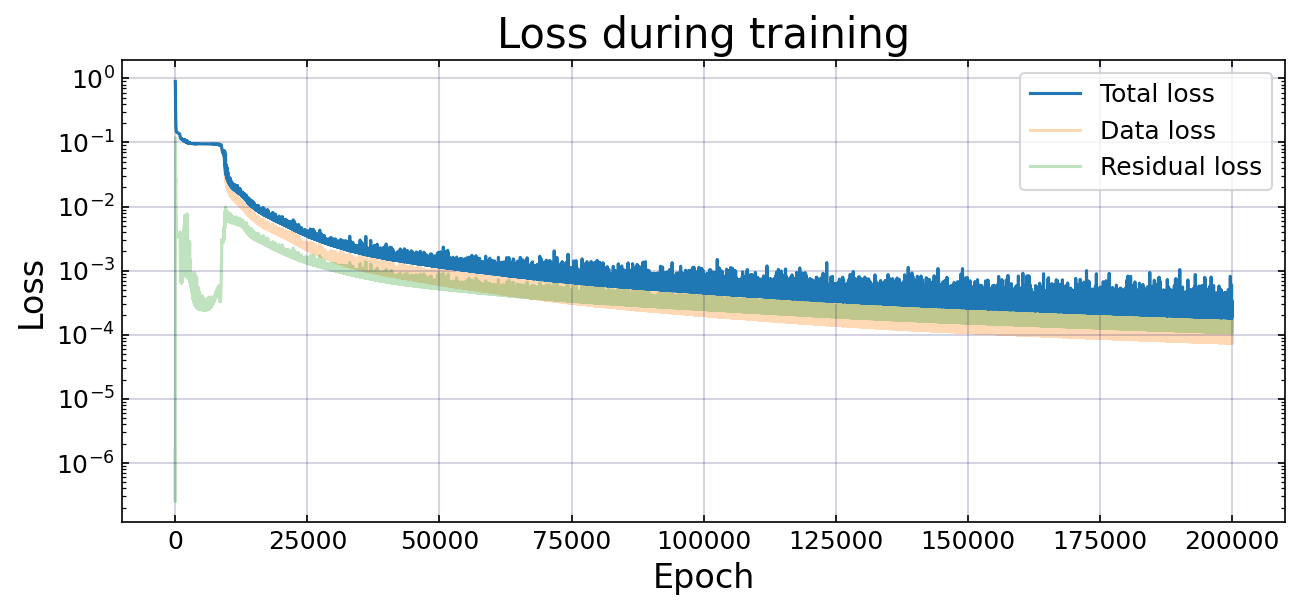

In [6]:
epochs = np.linspace(1, len(total_loss_list), len(total_loss_list))

fig, ax = plt.subplots(1,1,figsize = (10,4),dpi = 150)
ax.plot(epochs, total_loss_list, label='Total loss', zorder=2)
ax.plot(epochs, data_loss_list, label='Data loss', alpha=0.3, zorder=1)
ax.plot(epochs, residual_loss_list, label='Residual loss', alpha=0.3, zorder=1)
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('Loss',fontsize = 16)
ax.set_yscale('log')
ax.set_title('Loss during training',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='upper right',fontsize = 12)
plt.show()

## Evolution of $\lambda_1$, $\lambda_2$

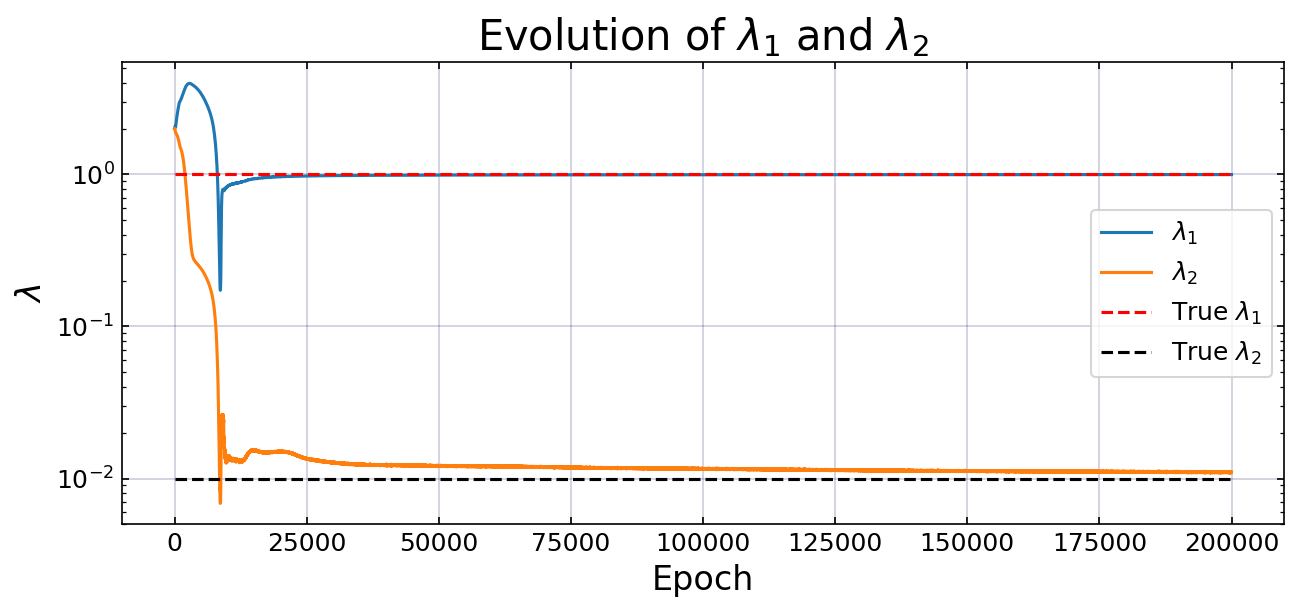

In [10]:
fig, ax = plt.subplots(1,1,figsize = (10,4),dpi = 150)
ax.plot(epochs, lambda1_list, label='$\\lambda_1$')
ax.plot(epochs, lambda2_list, label='$\\lambda_2$')
ax.hlines(1, 1, epochs[-1], linestyles='--', colors='red', label='True $\\lambda_1$')
ax.hlines(0.01, 1, epochs[-1], linestyles='--', colors='black', label='True $\\lambda_2$')
ax.set_xlabel('Epoch',fontsize = 16)
ax.set_ylabel('$\\lambda$',fontsize = 16)
ax.set_yscale('log')
ax.set_title('Evolution of $\\lambda_1$ and $\\lambda_2$',fontsize = 20)
ax.tick_params(labelsize=12, which='both',top=True, right = True, direction='in')
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.legend(loc='right',fontsize = 12)
plt.show()

## Save training progress

In [9]:
checkpoint = {
    "model_state_dict": model.state_dict(),

    "lambda1": lambda1.detach(),
    "lambda2": lambda2.detach(),

    "lbs": lbs.detach(),
    "ubs": ubs.detach(),

    "lambda1_list": lambda1_list,
    "lambda2_list": lambda2_list,
    "data_loss_list": data_loss_list,
    "residual_loss_list": residual_loss_list,
    "total_loss_list": total_loss_list,
}

torch.save(checkpoint, "navier_stokes_pinn_checkpoint.pt")

## Load checkpoint

In [2]:
model = nn.Sequential(
    nn.Linear(3, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 20),
    nn.Tanh(),
    nn.Linear(20, 2)
)

lambda1 = nn.Parameter(torch.tensor([2.0], dtype=torch.float))
lambda2 = nn.Parameter(torch.tensor([2.0], dtype=torch.float))

checkpoint = torch.load("navier_stokes_pinn_checkpoint.pt")

model.load_state_dict(checkpoint['model_state_dict'])

lambda1 = nn.Parameter(checkpoint['lambda1'].clone())
lambda2 = nn.Parameter(checkpoint['lambda2'].clone())

lbs = checkpoint["lbs"]
ubs = checkpoint["ubs"]

lambda1_list = checkpoint["lambda1_list"]
lambda2_list = checkpoint["lambda2_list"]
data_loss_list = checkpoint["data_loss_list"]
residual_loss_list = checkpoint["residual_loss_list"]
total_loss_list = checkpoint["total_loss_list"]

model.eval()

print('lambda1 =', lambda1.item())
print('lambda2 =', lambda2.item())

lambda1 = 0.997134268283844
lambda2 = 0.011006510816514492
